In [16]:
# 1. Carregar bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# 2. Carregar conjunto de dados (fisheriris)
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [ ]:
# 3. Dividir em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [4]:
# 4. Treinar o modelo Naive Bayes Gaussiano
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [12]:
# 5. Avaliar o modelo (acurácia)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {(acc*100):.2f} %")

Acurácia do modelo: 91.11 %


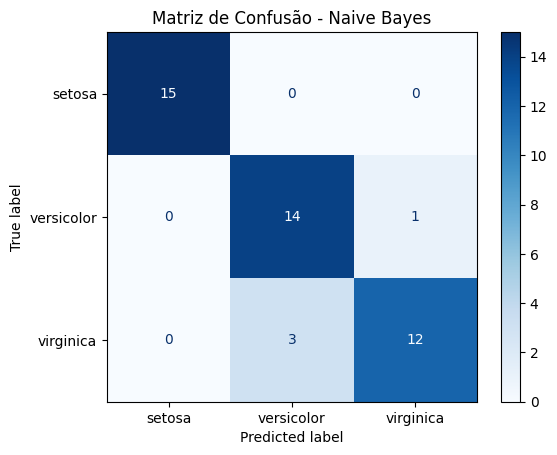

In [13]:
# 6. Plotar matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Naive Bayes")
plt.show()

In [23]:
# 7. Executar uma predição com um dado aleatório e avaliar resultado
idx = np.random.randint(0, X_test.shape[0])  # índice aleatório
sample = X_test[idx].reshape(1, -1)
true_label = y_test[idx]
pred_label = model.predict(sample)[0]
probas = model.predict_proba(sample)[0]

# Criar DataFrame com probabilidades
df_result = pd.DataFrame({
    "Classe": iris.target_names,
    "Probabilidade": probas
}).sort_values("Probabilidade", ascending=False)

print("Exemplo aleatório do conjunto de teste")
print("------------------------------------------------")
print(f"Amostra (features): {sample.tolist()[0]}")
print(f"Classe real:     {iris.target_names[true_label]}")
print(f"Classe prevista: {iris.target_names[pred_label]}")
print("\nProbabilidades por classe:")
print(df_result.to_string(index=False))

Exemplo aleatório do conjunto de teste
------------------------------------------------
Amostra (features): [5.8, 4.0, 1.2, 0.2]
Classe real:     setosa
Classe prevista: setosa

Probabilidades por classe:
    Classe  Probabilidade
    setosa   1.000000e+00
versicolor   5.486237e-20
 virginica   1.229818e-26
